![BasQ banner](logo_cropped.png)

# <b>Ground-State Energy of a Molecule with VQE </b>
**Author:** Benjamin Tirado  
**Created for:** BasQ Qiskit Fall Fest 2026 — Basque Quantum (BasQ)

<a id="goal"></a>
<div class="alert alert-block alert-success">
    
<b>Goal of this notebook: </b> Compute the **ground-state energy of the hydrogen molecule ($H_2$)** at its equilibrium bond distance using the **Variational Quantum Eigensolver (VQE)**. We will build the full workflow step by step: describe the molecule, map its electronic structure onto qubits with the **Jordan-Wigner** transformation, prepare a custom ansatz on top of a **Hartree-Fock** reference state, and optimize it to approximate the lowest energy. By the end, you will have a working template for the electronic-structure problem that you can extend to other molecules and geometries.
</div>

## <b>Background </b> <a id="background"></a>

One of the most natural applications of a quantum computer is simulating **quantum systems** themselves. In quantum chemistry, a central task is to find the **ground-state energy** of a molecule: the lowest possible energy of its electrons for a fixed arrangement of nuclei. This single number governs much of a molecule's chemistry, from its stability to the shape of its bonds.

Classically, the cost of solving the electronic Schrödinger equation exactly grows extremely fast with the number of electrons, quickly becoming intractable. This is where quantum computers offer a promising route: the state of a molecule can be encoded into qubits, and its energy estimated by preparing trial states and measuring them.

The **Variational Quantum Eigensolver (VQE)** is a hybrid quantum-classical algorithm built for exactly this task. It relies on the **variational principle**, which guarantees that for any trial state $|\psi(\vec{\theta})\rangle$,

$$
E(\vec{\theta}) = \frac{\langle \psi(\vec{\theta}) | \hat{H} | \psi(\vec{\theta}) \rangle}{\langle \psi(\vec{\theta}) | \psi(\vec{\theta}) \rangle} \;\geq\; E_0,
$$

where $\hat{H}$ is the molecular Hamiltonian and $E_0$ is the true ground-state energy. In other words, no trial state can ever give an energy *below* the ground state. VQE exploits this by parameterizing the trial state with a quantum circuit (the **ansatz**) and using a **classical optimizer** to tune the parameters $\vec{\theta}$ until the measured energy is as low as possible.

This idea underpins one of IBM Quantum's landmark demonstrations, *Hardware-efficient variational quantum eigensolver for small molecules and quantum magnets* (Kandala et al., Nature, 2017), which computed ground-state energies of small molecules on real superconducting hardware. In this tutorial we take the same conceptual workflow but keep it deliberately simple, working with H$_2$ on a simulator so that each ingredient is easy to inspect.

# <b>Defining the Molecule </b> <a id="molecule"></a>
The first step is to describe the physical system. A molecule is specified by the positions of its nuclei, its total charge, and its spin. For H$_2$ we place two hydrogen atoms along the $z$-axis, separated by different bond distances. Your goal is to calculate the **Potential Energy Surface** of $H_2$ and find the optimal bond length of the molecule.

We also choose a **basis set**, which defines the set of atomic orbitals used to represent the electrons. Here we use the minimal `sto3g` basis: with two hydrogen atoms it gives two spatial orbitals, i.e. four spin-orbitals, and therefore a small problem that is perfect for a first VQE.

The `PySCFDriver` runs a classical Hartree-Fock calculation behind the scenes and hands back an `ElectronicStructureProblem`. This object contains the **second-quantized Hamiltonian**

$$
\hat{H} = \sum_{pq} h_{pq}\, a_p^\dagger a_q + \tfrac{1}{2}\sum_{pqrs} h_{pqrs}\, a_p^\dagger a_q^\dagger a_r a_s,
$$

where the coefficients $h_{pq}$ and $h_{pqrs}$ are the one- and two-electron integrals computed from the chosen geometry and basis, and $a_p^\dagger$, $a_q$ are fermionic creation and annihilation operators.

# <b>The Ansatz: Hartree-Fock + Your Parametric Circuit </b> <a id="ansatz"></a>
VQE needs a **parameterized trial state**, the ansatz. A good ansatz should be expressive enough to reach the true ground state, yet not so large that the optimizer gets lost. For chemistry, a physically motivated and widely used choice is the **Unitary Coupled Cluster with Singles and Doubles (UCCSD)** ansatz. Although you can choose any ansatz that provides energies withing chemical accuracy of 1e-3.

The idea is to start from a good, cheap approximation and improve it:

- **Hartree-Fock (HF) reference state.** This is the mean-field solution, where each electron occupies the lowest available spin-orbitals. On qubits it is simply the computational basis state with the occupied orbitals set to $|1\rangle$. It is our starting point.
- **UCCSD excitations.** On top of HF, UCCSD applies parameterized *single* and *double* excitations, which move electrons from occupied into virtual (empty) orbitals. Formally the trial state is

$$
|\psi(\vec{\theta})\rangle = e^{\hat{T}(\vec{\theta}) - \hat{T}^\dagger(\vec{\theta})} \, |\text{HF}\rangle,
$$

where $\hat{T}$ collects the single and double excitation operators and $\vec{\theta}$ are the parameters VQE will optimize. Capturing these excitations is what lets the ansatz describe **electron correlation** — the physics that Hartree-Fock alone misses.

In Qiskit Nature, `UCCSD` builds this circuit for us, and we pass it a `HartreeFock` object as its `initial_state`.

# <b>Running VQE </b> <a id="vqe"></a>
We now have every ingredient VQE needs:

1. An **Estimator primitive**, which evaluates the expectation value $\langle \psi(\vec{\theta}) | \hat{H} | \psi(\vec{\theta})\rangle$. Here we use the `StatevectorEstimator`, an exact, noiseless simulator that is ideal for understanding the algorithm before moving to hardware.
2. The **ansatz**, our Your circuit + Hartree-Fock trial state.
3. A **classical optimizer**, which proposes new parameters to lower the energy. We use `SLSQP`, a gradient-based optimizer that works well for smooth, low-dimensional problems like this one.

A natural starting point for the parameters is all zeros: this corresponds to applying no excitations, so the trial state is exactly the Hartree-Fock state. The optimizer then explores from there.

The `compute_minimum_eigenvalue` from Qiskit Nature conveniently ties the mapper and the solver together and, finally, **we add back the nuclear repulsion energy** so that the number we get out is the total molecular energy.

If everything went well, the VQE energy should agree with the exact diagonalization to well within **chemical accuracy**, usually defined as $1.6 \times 10^{-3}$ Hartree ($\approx 1$ kcal/mol). This is the precision threshold chemists care about, because it is roughly the accuracy needed to predict reaction energies reliably.

# <b>Pre-requisites </b> <a id="prereq"></a>
For starters, make sure you have installed the Qiskit SDK and its supporting modules: `qiskit_aer` (for noiseless simulations) and `qiskit_ibm_runtime` (for real-hardware experiments), as well as the visualization package `qiskit[visualization]`. For the chemistry-specific parts we use `qiskit_nature`, which builds the molecular problem and the fermion-to-qubit mappings, together with the classical chemistry backend `pyscf` that computes the one- and two-electron integrals. We also use `qiskit_algorithms` for the VQE routine and its optimizers.

> **Note:** `qiskit_nature` needs a classical electronic-structure driver to obtain the molecular integrals. Here we use PySCF via `PySCFDriver`. On some systems (e.g. native Windows) PySCF can be tricky to install; if so, running inside WSL or a Linux/macOS environment is the smoothest option.

In [1]:
%pip install qiskit qiskit_aer qiskit_ibm_runtime qiskit[visualization] qiskit_nature pyscf qiskit_algorithms

  Using cached qiskit_algorithms-0.4.0-py3-none-any.whl.metadata (4.7 kB)
  Using cached requests_ntlm-1.3.0-py3-none-any.whl.metadata (2.4 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 4.6 MB/s  0:00:02 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 6.9 MB/s  0:00:02m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 6.3 MB/s  0:00:01 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 5.7 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 7.8 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 541.5/541.5 kB 7.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 6.1 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 MB 8.2 MB/s  0:00:06m0:00:0100:01
Using cached qiskit_algorithms-0.4.0-py3-none-any

# Molecular Data Cache (Helper)

Create the molecular data cache to define the problem and precompute some of the molecular properties of our systems using PySCFDriver

In [5]:
import numpy as np

from qiskit_nature.units import DistanceUnit
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.second_q.mappers import JordanWignerMapper


dists = [0.635, 0.735, 0.835, 0.935, 1.035]

cache = {}

mapper = JordanWignerMapper()

for d in dists:

    print(f"Generating cache for H2 at {d} Å")

    driver = PySCFDriver(
        atom=f"H 0 0 0; H 0 0 {d}",
        basis="sto3g",
        charge=0,
        spin=0,
        unit=DistanceUnit.ANGSTROM,
    )

    problem = driver.run()

    # Fermionic Hamiltonian
    fermionic_op = problem.hamiltonian.second_q_op()

    # Jordan-Wigner Hamiltonian
    qubit_op = mapper.map(fermionic_op)
    print(qubit_op)

    cache[d] = {
        "qubit_op": qubit_op,
        "num_spatial_orbitals": problem.num_spatial_orbitals,
        "num_spin_orbitals": problem.num_spin_orbitals,
        "num_particles": problem.num_particles,
        "nuclear_repulsion_energy": problem.nuclear_repulsion_energy
    }

Generating cache for H2 at 0.635 Å


SparsePauliOp(['IIII', 'IIIZ', 'IIZI', 'IZII', 'ZIII', 'IIZZ', 'IZIZ', 'ZIIZ', 'YYYY', 'XXYY', 'YYXX', 'XXXX', 'IZZI', 'ZIZI', 'ZZII'],
              coeffs=[-0.76890004+0.j,  0.18860219+0.j, -0.27801276+0.j,  0.18860219+0.j,
 -0.27801276+0.j,  0.12671758+0.j,  0.1736864 +0.j,  0.17060055+0.j,
  0.04388298+0.j,  0.04388298+0.j,  0.04388298+0.j,  0.04388298+0.j,
  0.17060055+0.j,  0.17939851+0.j,  0.12671758+0.j])
Generating cache for H2 at 0.735 Å
SparsePauliOp(['IIII', 'IIIZ', 'IIZI', 'IZII', 'ZIII', 'IIZZ', 'IZIZ', 'ZIIZ', 'YYYY', 'XXYY', 'YYXX', 'XXXX', 'IZZI', 'ZIZI', 'ZZII'],
              coeffs=[-0.81054798+0.j,  0.17218393+0.j, -0.22575349+0.j,  0.17218393+0.j,
 -0.22575349+0.j,  0.12091263+0.j,  0.16892754+0.j,  0.16614543+0.j,
  0.0452328 +0.j,  0.0452328 +0.j,  0.0452328 +0.j,  0.0452328 +0.j,
  0.16614543+0.j,  0.17464343+0.j,  0.12091263+0.j])
Generating cache for H2 at 0.835 Å
SparsePauliOp(['IIII', 'IIIZ', 'IIZI', 'IZII', 'ZIII', 'IIZZ', 'IZIZ', 'ZIIZ', 'YYYY', 'XXYY', '

#Challenge Code

In [8]:
import numpy as np

from qiskit_nature.units import DistanceUnit
from qiskit_nature.second_q.drivers import PySCFDriver
from qiskit_nature.second_q.mappers import JordanWignerMapper # , QubitConverter # Import QubitConverter
from qiskit_nature.second_q.circuit.library import UCCSD, HartreeFock
from qiskit_nature.second_q.algorithms import GroundStateEigensolver

from qiskit_algorithms import VQE
from qiskit_algorithms.optimizers import SLSQP
from qiskit.primitives import StatevectorEstimator

from qiskit.circuit import ParameterVector
from qiskit import QuantumCircuit

# ============================================================
# Distances
# ============================================================

dists = [0.635, 0.735, 0.835, 0.935, 1.035]


def make_PES(dists, mol_data):
    ideal_vqe_energies = []
    for d in dists:

        print("\n======================================")
        print(f"H2 distance = {d} Å")
        print("======================================")

        qubit_op = mol_data[d]["qubit_op"]
        num_particles = mol_data[d]["num_particles"]
        num_spatial_orbitals = mol_data[d]["num_spatial_orbitals"]
        # num_spin_orbitals = mol_data[d]["num_spin_orbitals"] # This is not needed directly for UCCSD
        nuclear_repulsion_energy = mol_data[d]["nuclear_repulsion_energy"]

        mapper = JordanWignerMapper()
        # qubit_converter = QubitConverter(mapper) # Create QubitConverter from the mapper

        # ====================================================
        # Hartree-Fock
        # ====================================================

        hf_state = HartreeFock(
            num_spatial_orbitals,
            num_particles,
            mapper,
        )

        # ====================================================
        # 
        

        # ====================================================

        #### YOUR CODE HERE (BELOW)
        ansatz = UCCSD(
            num_spatial_orbitals=num_spatial_orbitals,
            num_particles=num_particles,
            qubit_mapper=mapper,
            initial_state=hf_state
        )

        #### DO NOT EDIT BELOW THIS LINE

        # ====================================================
        # IDEAL STATEVECTOR VQE
        # ====================================================

        sv_estimator = StatevectorEstimator()

        optimizer = SLSQP()

        vqe = VQE(
            sv_estimator,
            ansatz,
            optimizer,
        )

        # Start at Hartree-Fock (all zeros corresponds to no excitations from HF)
        # The initial_point should match the number of parameters in the ansatz.
        # UCCSD automatically sets up its parameters, so we just use its num_parameters.
        vqe.initial_point = np.zeros(
            ansatz.num_parameters
        )

        vqe_result = vqe.compute_minimum_eigenvalue(qubit_op)

        ideal_vqe_energy = vqe_result.eigenvalue.real + nuclear_repulsion_energy

        print(
            f"Ideal VQE energy   : "
            f"{ideal_vqe_energy:.8f} Ha"
        )
        # print(f"Optimal parameters : {optimal_params}")

        ideal_vqe_energies.append(ideal_vqe_energy)
    return ideal_vqe_energies


# Results (Optimal Bond Length)

Use the cell below to visualize the Potential Energy Surface of $H_2$. If done correctly, you should be able to clearly see a minimum point in the graph which is the optimal bond length of this molecule!


H2 distance = 0.635 Å


/home/tuthuanvanvn/miniconda3/envs/ibm/lib/python3.13/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:653: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
/home/tuthuanvanvn/miniconda3/envs/ibm/lib/python3.13/site-packages/scipy/sparse/linalg/_matfuncs.py:706: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)


Ideal VQE energy   : -1.12669582 Ha

H2 distance = 0.735 Å
Ideal VQE energy   : -1.13730604 Ha

H2 distance = 0.835 Å
Ideal VQE energy   : -1.13034079 Ha

H2 distance = 0.935 Å
Ideal VQE energy   : -1.11422548 Ha

H2 distance = 1.035 Å
Ideal VQE energy   : -1.09363195 Ha


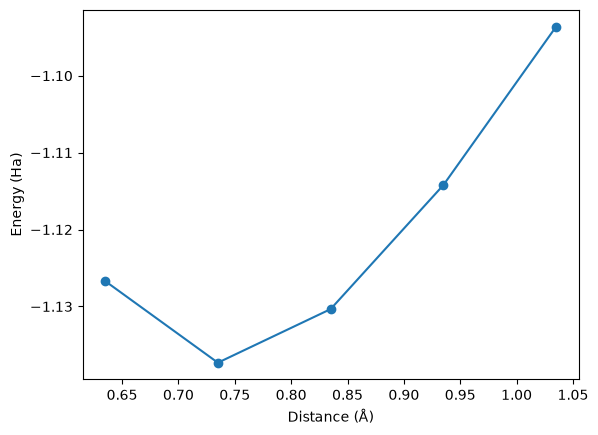

In [9]:
### Run your function

vqe_energies = make_PES(dists, cache)

import matplotlib.pyplot as plt

plt.plot(dists, vqe_energies, "o-")
plt.xlabel("Distance (Å)")
plt.ylabel("Energy (Ha)")
plt.show()

# <b>Useful resources </b> <a id="use"></a>

The following resources may be useful when extending this introductory VQE example toward the full challenge.

### <b>Qiskit Nature (quantum chemistry) </b>

- [Qiskit Nature documentation](https://qiskit-community.github.io/qiskit-nature/)  
  Entry point for building electronic-structure problems, drivers, mappers, and chemistry ansätze.

- [Ground-state solvers tutorial](https://qiskit-community.github.io/qiskit-nature/tutorials/03_ground_state_solvers.html)  
  Step-by-step tutorial on finding molecular ground states with VQE and classical solvers — the closest reference to this notebook.

- [Electronic structure problem tutorial](https://qiskit-community.github.io/qiskit-nature/tutorials/01_electronic_structure.html)  
  Explains drivers, basis sets, and how the second-quantized Hamiltonian is constructed.

- [Qubit mappers tutorial](https://qiskit-community.github.io/qiskit-nature/tutorials/06_qubit_mappers.html)  
  Compares Jordan-Wigner, parity, and Bravyi-Kitaev mappings, including qubit tapering via symmetries — directly relevant to the intermediate challenge.

- [UCCSD ansatz documentation](https://qiskit-community.github.io/qiskit-nature/stubs/qiskit_nature.second_q.circuit.library.UCCSD.html)  
  Reference page for the UCCSD variational form used in this notebook.

### <b>Variational algorithms and optimizers </b>

- [VQE documentation](https://qiskit-community.github.io/qiskit-algorithms/stubs/qiskit_algorithms.VQE.html)  
  Reference page for the Variational Quantum Eigensolver class.

- [Qiskit Algorithms optimizers](https://qiskit-community.github.io/qiskit-algorithms/apidocs/qiskit_algorithms.optimizers.html)  
  Reference page for classical optimizers such as `SLSQP`, `COBYLA`, `SPSA`, and others to experiment with.

- [AdaptVQE how-to](https://qiskit-community.github.io/qiskit-nature/howtos/adapt_vqe.html)  
  Builds an ansatz adaptively, a useful stepping stone toward the advanced challenge.

- [Variational quantum algorithms course](https://quantum.cloud.ibm.com/learning/en/courses/utility-scale-quantum-computing/variational-quantum-algorithms)  
  IBM Quantum learning material on the broader family of hybrid variational algorithms.

### <b>Hardware execution, transpilation, and error mitigation </b>

- [Qiskit documentation](https://quantum.cloud.ibm.com/docs/guides/tools-intro)  
  General entry point for circuits, primitives, transpilation, and runtime execution on IBM Quantum.

- [Transpile with pass managers](https://quantum.cloud.ibm.com/docs/guides/transpile-with-pass-managers)  
  How to transpile circuits for a specific backend and its connectivity.

- [Error mitigation and suppression techniques](https://quantum.cloud.ibm.com/docs/guides/error-mitigation-and-suppression-techniques)  
  Overview of the resilience options available through Qiskit Runtime.

- [Combine error mitigation options with the Estimator primitive](https://quantum.cloud.ibm.com/docs/tutorials/combine-error-mitigation-techniques)  
  Tutorial on dynamical decoupling, measurement-error mitigation, gate twirling, and zero-noise extrapolation.

### <b>Background reading </b>

- [Kandala et al., *Hardware-efficient variational quantum eigensolver for small molecules and quantum magnets*, Nature (2017)](https://www.nature.com/articles/nature23879)  
  The IBM Quantum paper that inspires this challenge track.

## <b>Credits and license</b>

This notebook was written by **Benjamin Tirado** for the **BasQ Qiskit Fall Fest 2026**, organised by Basque Quantum (BasQ).

© 2026 Benjamin Tirado. The text, figures and explanations are released under
[CC BY 4.0](https://creativecommons.org/licenses/by/4.0/); the code is released under the
[Apache License 2.0](https://www.apache.org/licenses/LICENSE-2.0), the same license as Qiskit.

You are welcome to run, adapt and share this material — including as a starting point for your own
challenge submission — provided the attribution above is kept. If you reuse it publicly, please cite it as:

> B. Tirado, *Ground-State Energy of a Molecule with VQE*, tutorial notebook, BasQ Qiskit Fall Fest, 2026.

Built with [Qiskit](https://www.ibm.com/quantum/qiskit), [Qiskit Nature](https://qiskit-community.github.io/qiskit-nature/)
and [PySCF](https://pyscf.org/), which remain the property of their respective authors and are used
under their own licenses.

*Questions, corrections or suggestions:* benjamin.tirado@ehu.eus